In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords        
from nltk.tokenize import word_tokenize  
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)

nltk.download('punkt_tab')
nltk.download('stopwords')

d:\ml_research_llm\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\human-26\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\human-26\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
"""
지금 현재 ㄹ로우데이터 구조
컬럼: text(에세이 텍스트) , label(0:사람이 작성, 1:AI작성), prompt_name(에세이 주제), source(데이터 출처)
데이터 전처리를 해야지 여러가지 방법으로 분석이 가능하기때문에 다양한 전처리 과정이 피룡
"""

raw_df = pd.read_csv('../data/rawdata.csv')

# Rdizzl3_seven는 대회에 참가한 사람이 테스트해놓은 결과 컬럼이라 삭제함
if 'RDizzl3_seven' in raw_df.columns:
    raw_df = raw_df.drop(columns=['RDizzl3_seven'])

rename_map = {
    'text': '텍스트', 'label': '라벨', 'prompt_name': '검색어',
    'source': '출처', 'clean_text': '불용어_제거', 'text_len': '문장_길이',
    'word_count': '단어_개수', 'avg_word_len': '단어_평균길이',
    'lexical_diversity': '어휘_다양성', 'word_density': '단어_밀도',
    'punc_count': '특문_개수'
}
df = raw_df.rename(columns=rename_map)
print(f"데이터 로드 완료 총 {len(df)}개의 행이 있습니다.")
df.head()

데이터 로드 완료 총 44868개의 행이 있습니다.


,텍스트,라벨,검색어,출처
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus
3,Phones & Driving\n\nDrivers should not be able...,0,Phones and driving,persuade_corpus
4,Cell Phone Operation While Driving\n\nThe abil...,0,Phones and driving,persuade_corpus


In [3]:
'''
불용어를 제거하는 단계 
불용어란 the, a, an, i, am  등등 분석에 도움이 되지 않는 단어들
의미구분에 도움이 안되는 단어가 모델학습을 방해하기 때문에 삭제합니다
'''
print("불용어 제거 시작")
stop_words = set(stopwords.words('english'))

def process_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    return " ".join([word for word in tokens if word not in stop_words])

df['불용어_제거'] = df['텍스트'].apply(process_text)
df[['텍스트', '불용어_제거']].head()

전처리 시작


,텍스트,불용어_제거
0,Phones\n\nModern humans today are always on th...,phones modern humans today always phone always...
1,This essay will explain if drivers should or s...,essay explain drivers able use electronic devi...
2,Driving while the use of cellular devices\n\nT...,driving use cellular devices today society tho...
3,Phones & Driving\n\nDrivers should not be able...,phones driving drivers able use phones operati...
4,Cell Phone Operation While Driving\n\nThe abil...,cell phone operation driving ability stay conn...


In [9]:
'''
다양한 분석을 위해 변수를 생성 << feature engineering
1. 기본 변수: 문장길이, 단어의 개수
2. 평균 단어 길이: 문장길이/단어개수  --> 높을수록 한문장안에 단어의 개수를 많이 사용안했다는 의미
3. 어휘 다양성: 중복된단어를 제거한 문장의 길이/문장의 길이  --> 중복되지 않은 단어가 많은 문장일 수록 글이 풍성함
4. 단어 밀도: 단어개수/문장길이 --> 한문장안에 단어가얼마나 들어갔냐(밀도) --> 단어가 많을 수록 밀도가 높아짐
5. 특수문자 개수: 사람과 ai의 틋수문자 사용 습관확인
'''

print("변수 생성중~")
df['문장_길이'] = df['텍스트'].apply(len)
df['단어_개수'] = df['텍스트'].apply(lambda x: len(x.split()))
df['단어_평균길이'] = df['문장_길이'] / df['단어_개수']

def get_diversity(text):
    words = text.lower().split()
    if len(words) == 0: return 0
    return len(set(words)) / len(words)

df['어휘_다양성'] = df['텍스트'].apply(get_diversity)
df['단어_밀도'] = df['단어_개수'] / df['문장_길이']
df['특문_개수'] = df['텍스트'].apply(lambda x: len([char for char in x if char in '.,?!:;']))

df[['문장_길이', '단어_개수', '어휘_다양성', '단어_밀도', '특문_개수']].head()

변수 생성중~


,문장_길이,단어_개수,어휘_다양성,단어_밀도,특문_개수
0,2029,379,0.525066,0.186792,32
1,2141,366,0.469945,0.170948,42
2,1044,178,0.612360,0.170498,13
3,1243,212,0.537736,0.170555,20
4,1911,332,0.584337,0.173731,28


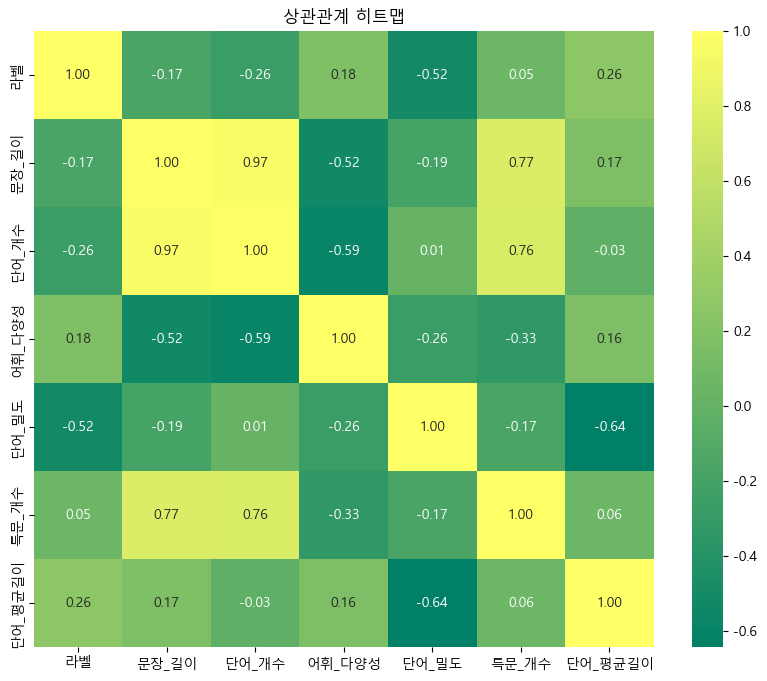

In [ ]:
'''
상관관계 히트맵을 시각화
라벨과 가장 연관있는 데이터는  단어_밀도(-0.52)
가장 연관없는 데이터는 특수문자개수(0.05)
'''
analysis_cols = ['라벨', '문장_길이', '단어_개수', '어휘_다양성', '단어_밀도', '특문_개수', '단어_평균길이']
plt.figure(figsize=(10, 8))
sns.heatmap(df[analysis_cols].corr(), annot=True, cmap='summer', fmt='.2f')
plt.title('상관관계 히트맵')
plt.show()

In [7]:
'''
학습을 위해 새로운 데이터셋 생성
라벨값(0,1)이랑 3가지 컬럼의 평균값 비교
사람인 경우와 ai인경우에 누가 더 어휘를 다양하게 쓰고 단어밀도가 높고 특수문자를 많이 사용하는가
비교결과 유사하게 나옴..
'''

save_path = '../data/processed/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

df.to_csv(os.path.join(save_path, "refined_data.csv"), index=False, encoding='utf-8-sig')
print("가공된 데이터 저장 완료")

print("\n--- [라벨별 주요 지표 평균] ---")
print(df.groupby('라벨')[['어휘_다양성', '단어_밀도', '특문_개수']].mean())

가공된 데이터 저장 완료

--- [라벨별 주요 지표 평균] ---
      어휘_다양성     단어_밀도      특문_개수
라벨                               
0   0.478516  0.180338  36.439480
1   0.510351  0.164869  38.378579
